## STEP 1 — Import Libraries

In [1]:
# Step 1: Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# graph style
sns.set(style="whitegrid")


## STEP 2 — Dataset Load

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## STEP 3 — Basic Info

In [5]:
 df.shape

(9994, 21)

In [8]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [9]:
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Q

## STEP 4 — Missing Values

In [10]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## STEP 5 — Descriptive Statistics


In [11]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## STEP 6 — Data Summary Table

In [12]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum()
})

summary


,Column,Data Type,Missing Values
Row ID,Row ID,int64,0
Order ID,Order ID,object,0
Order Date,Order Date,object,0
Ship Date,Ship Date,object,0
Ship Mode,Ship Mode,object,0
Customer ID,Customer ID,object,0
Customer Name,Customer Name,object,0
Segment,Segment,object,0
Country,Country,object,0
City,City,object,0


## STEP 7 — Date Convert

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


## STEP 8 — Distribution Graphs

### Sales distribution

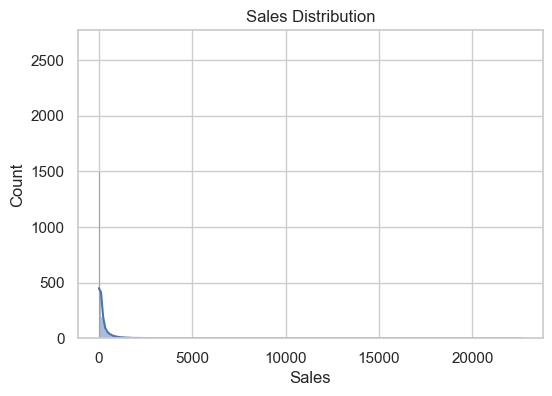

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()


### Profit distribution

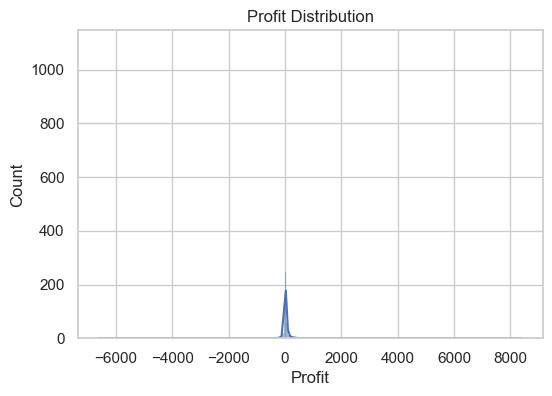

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Profit'], kde=True)
plt.title("Profit Distribution")
plt.show()


## STEP 9 — Correlation Heatmap

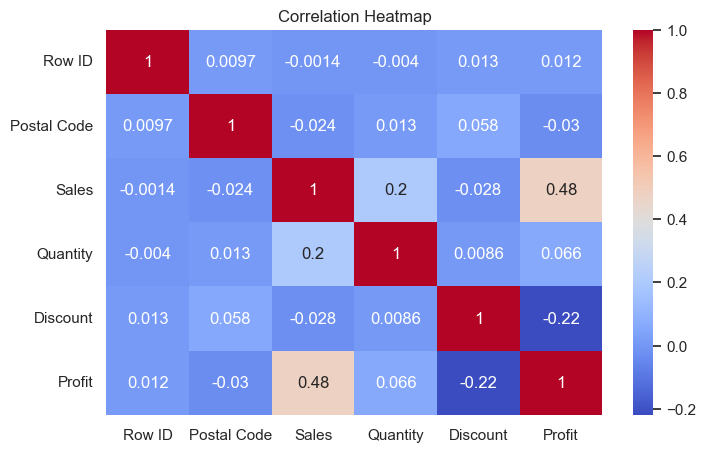

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## STEP 10 — Sales by Category

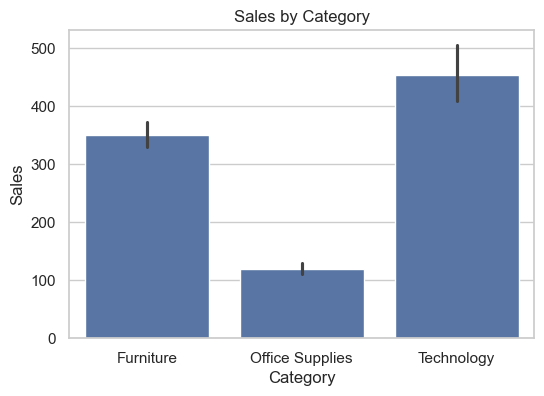

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()


## STEP 11 — Profit by Region

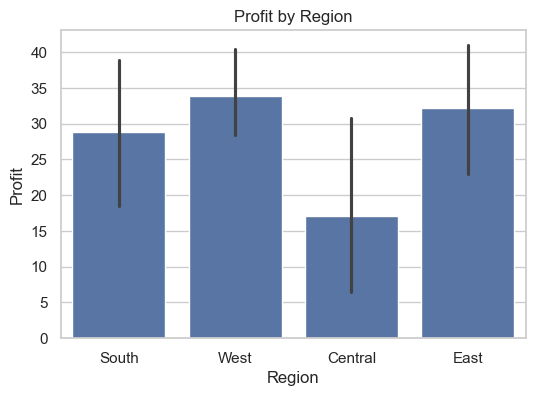

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.show()


## STEP 12 — Outliers Check

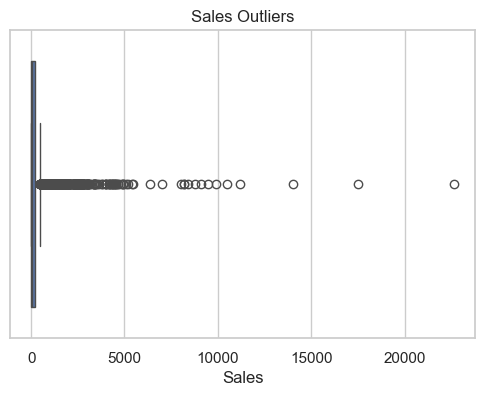

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()


## STEP 13 — Time Analysis

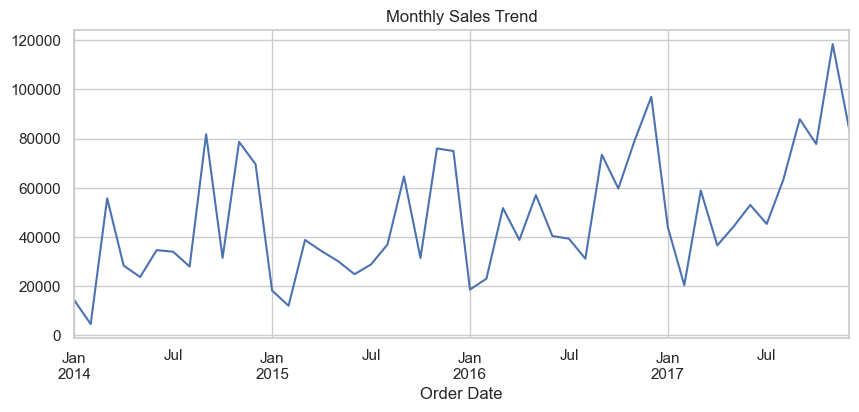

In [20]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period("M"))['Sales'].sum()

monthly_sales.plot(figsize=(10,4))
plt.title("Monthly Sales Trend")
plt.show()


In [21]:
print("Sales Skew:", df['Sales'].skew())
print("Sales Kurtosis:", df['Sales'].kurt())

print("Profit Skew:", df['Profit'].skew())
print("Profit Kurtosis:", df['Profit'].kurt())


Sales Skew: 12.97275234181623
Sales Kurtosis: 305.311753246823
Profit Skew: 7.561431562468343
Profit Kurtosis: 397.1885145524141


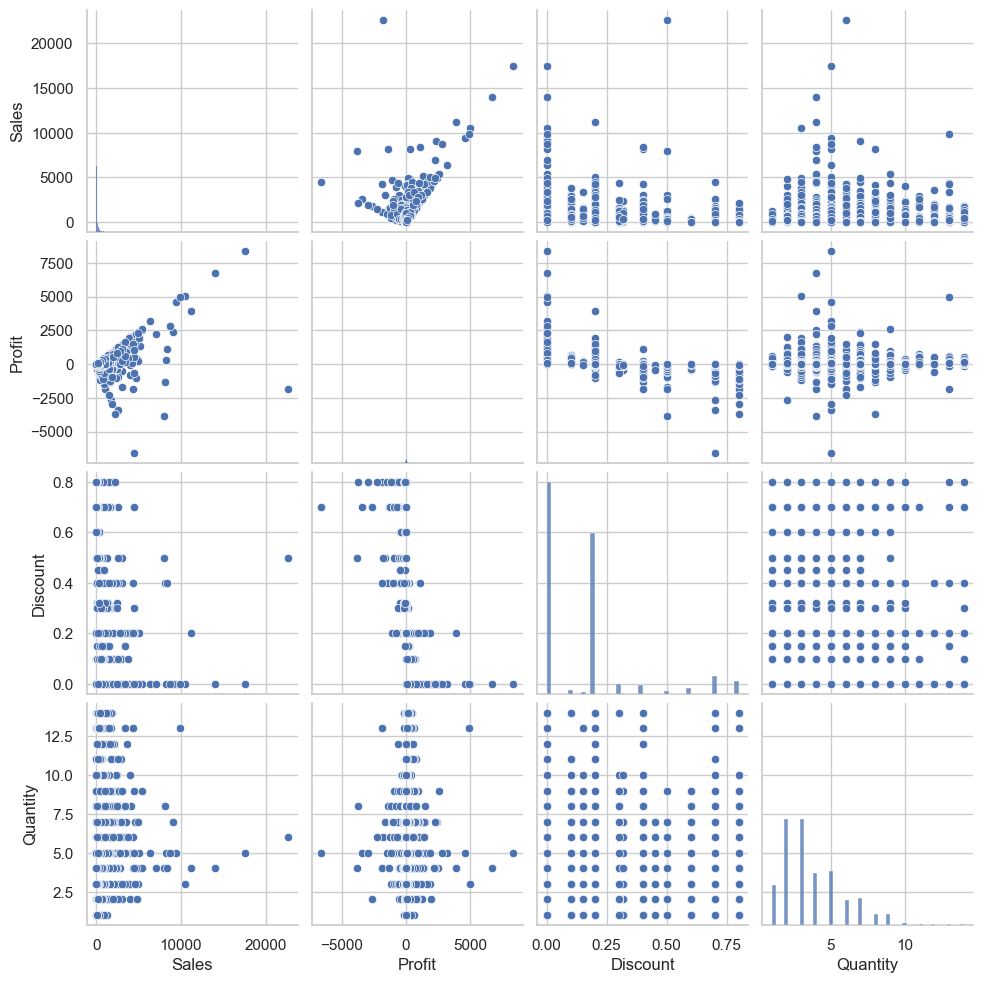

In [22]:
sns.pairplot(df[['Sales','Profit','Discount','Quantity']])
plt.show()


Sales and Profit distributions are highly skewed with extreme outliers.
High kurtosis values indicate presence of heavy tails and extreme values.
